/home/etrevol/work/acc_disk/data/acc_disk.block0.out1.00000.tab
Data keys: dict_keys(['i', 'x1v', 'rho', 'press', 'vel1', 'vel2', 'vel3'])


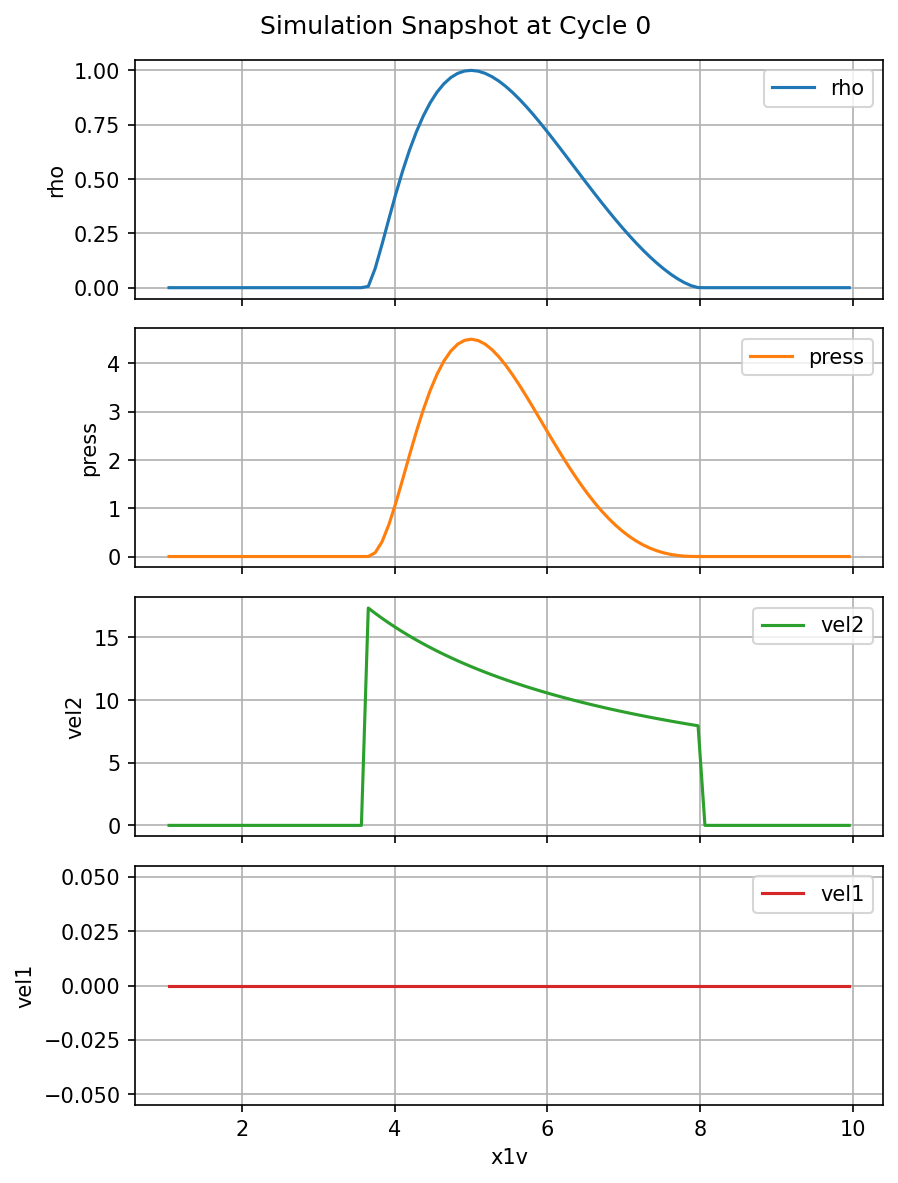

In [7]:
# %config InlineBackend.figure_format = 'retina'

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Function to read the ASCII data file
def read_athena_data(filename):
    with open(filename, "r") as f:
        lines = f.readlines()

    # Extract header info
    headers = lines[1].strip("# \n").split()
    data = np.loadtxt(lines[2:])  # Read numerical data

    # Create a dictionary of columns
    data_dict = {headers[i]: data[:, i] for i in range(len(headers))}
    return data_dict

# Function to plot variables at a given cycle index
def multiplot_snapshot(data_dict, cycle_index):
    x1v = data_dict["x1v"]
    variables = ["rho", "press", "vel2", "vel1"]

    fig, axes = plt.subplots(len(variables), 1, figsize=(6, 8), dpi=150, sharex=True)

    for i, var in enumerate(variables):
        if var in data_dict:
            axes[i].plot(x1v, data_dict[var], label=var, color=f"C{i}")
            axes[i].set_ylabel(var)
            axes[i].legend()
            axes[i].grid()

    axes[-1].set_xlabel("x1v")
    fig.suptitle(f"Simulation Snapshot at Cycle {cycle_index}")
    plt.tight_layout()
    plt.show()

path0 = "/home/etrevol/work/acc_disk/"
os.chdir(path0)

filename = "acc_disk.block0.out1.00000.tab"
filename = path0 + "data/" + filename
print(filename)

data_dict = read_athena_data(filename)
print("Data keys:", data_dict.keys())

multiplot_snapshot(data_dict, cycle_index=0)  # Adjust cycle index as needed

Графіки та анімація збережені у папку: /home/etrevol/work/acc_disk/plots/prim


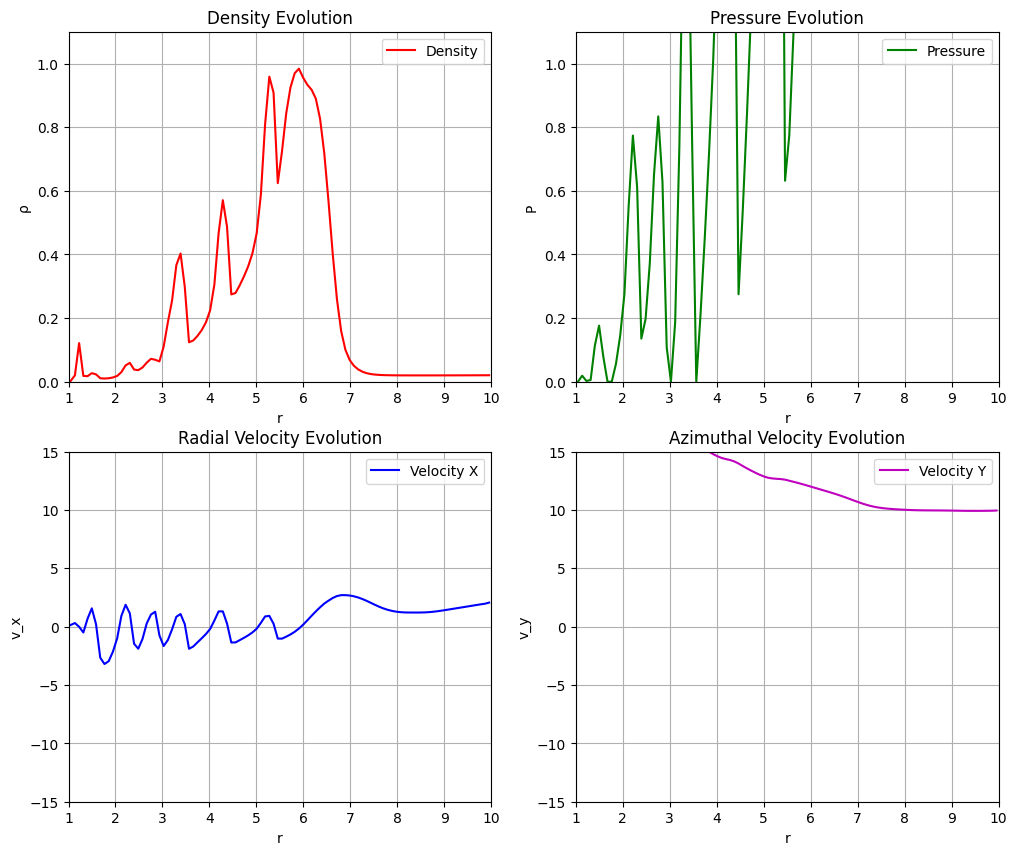

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os

# Папка з вихідними даними
data_dir = "/home/etrevol/work/acc_disk/data"
file_pattern = "acc_disk.block0.out1.{:05d}.tab"  # Формат імені файлів

# Папка для збереження результатів
output_dir = "/home/etrevol/work/acc_disk/plots/prim"
os.makedirs(output_dir, exist_ok=True)

# Налаштування
# Автоматично знаходимо доступні файли
all_files = sorted([
    f for f in os.listdir(data_dir)
    if f.startswith("acc_disk.block0.out1.") and f.endswith(".tab")
])

# Витягуємо доступні frame-номери
available_frames = sorted([
    int(f.split('.')[-2]) for f in all_files
])

num_frames = len(available_frames)
skip_rows = 2  # Пропускаємо заголовки

# Шляхи для збереження
output_image_density = os.path.join(output_dir, "acc_disk_initial_density.png")
output_image_pressure = os.path.join(output_dir, "acc_disk_initial_pressure.png")
output_image_velocity_x = os.path.join(output_dir, "acc_disk_initial_velocity_x.png")
output_image_velocity_y = os.path.join(output_dir, "acc_disk_initial_velocity_y.png")
output_video = os.path.join(output_dir, "acc_disk.mp4")

# Створюємо фігуру для анімації
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()
line1, = ax[0].plot([], [], 'r-', label="Density")
line2, = ax[1].plot([], [], 'g-', label="Pressure")
line3, = ax[2].plot([], [], 'b-', label="Velocity X")
line4, = ax[3].plot([], [], 'm-', label="Velocity Y")

# Налаштування осей та підписів
for a in ax:
    a.set_xlim(1, 10)
    a.set_xlabel("r")
    a.grid(True)
ax[0].set_ylim(0, 1.1)
ax[0].set_ylabel("ρ")
ax[0].set_title("Density Evolution")
ax[0].legend()
ax[1].set_ylim(0, 1.1)
ax[1].set_ylabel("P")
ax[1].set_title("Pressure Evolution")
ax[1].legend()
ax[2].set_ylim(-15, 15)
ax[2].set_ylabel("v_x")
ax[2].set_title("Radial Velocity Evolution")
ax[2].legend()
ax[3].set_ylim(-15, 15)
ax[3].set_ylabel("v_y")
ax[3].set_title("Azimuthal Velocity Evolution")
ax[3].legend()

# Вибір номеру файлу для побудови початкових графіків
initial_frame_number = int(input(f"Введіть номер фрейму для побудови графіків (0 - {available_frames[-1]}): "))
initial_file = os.path.join(data_dir, file_pattern.format(initial_frame_number))
if os.path.exists(initial_file):
    data = np.loadtxt(initial_file, skiprows=skip_rows)
    r_init = data[:, 1]  # Радіус
    rho_init = data[:, 2]  # Густина
    P_init = data[:, 3]  # Тиск
    vx_init = data[:, 4]  # Швидкість X
    vy_init = data[:, 5]  # Швидкість Y

    # Зберігаємо графіки в папку
    plt.figure(figsize=(8, 6))
    plt.plot(r_init, rho_init, 'r-', label=f"Initial Density (frame {initial_frame_number})")
    plt.xlabel("r")
    plt.ylabel("ρ")
    plt.title("Initial Density Distribution")
    plt.legend()
    plt.grid()
    plt.savefig(output_image_density)
    plt.close()

    plt.figure(figsize=(8, 6))
    plt.plot(r_init, P_init, 'g-', label=f"Initial Pressure (frame {initial_frame_number})")
    plt.xlabel("r")
    plt.ylabel("P")
    plt.title("Initial Pressure Distribution")
    plt.legend()
    plt.grid()
    plt.savefig(output_image_pressure)
    plt.close()

    plt.figure(figsize=(8, 6))
    plt.plot(r_init, vx_init, 'b-', label=f"Initial Velocity X (frame {initial_frame_number})")
    plt.xlabel("r")
    plt.ylabel("v_x")
    plt.title("Initial Radial Velocity Distribution")
    plt.legend()
    plt.grid()
    plt.savefig(output_image_velocity_x)
    plt.close()

    plt.figure(figsize=(8, 6))
    plt.plot(r_init, vy_init, 'm-', label=f"Initial Velocity Y (frame {initial_frame_number})")
    plt.xlabel("r")
    plt.ylabel("v_y")
    plt.title("Initial Azimuthal Velocity Distribution")
    plt.legend()
    plt.grid()
    plt.savefig(output_image_velocity_y)
    plt.close()

# Функція ініціалізації для анімації
def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    line4.set_data([], [])
    return line1, line2, line3, line4

# Функція оновлення для анімації
def update(frame):
    filename = os.path.join(data_dir, file_pattern.format(frame))
    if not os.path.exists(filename):
        return line1, line2, line3, line4

    data = np.loadtxt(filename, skiprows=skip_rows)
    r = data[:, 1]
    rho = data[:, 2]
    P = data[:, 3]
    vx = data[:, 4]
    vy = data[:, 5]

    line1.set_data(r, rho)
    line2.set_data(r, P)
    line3.set_data(r, vx)
    line4.set_data(r, vy)
    return line1, line2, line3, line4

# Створення анімації
ani = animation.FuncAnimation(fig, update, frames=num_frames, init_func=init, blit=True)
ani.save(output_video, fps=5)

print(f"Графіки та анімація збережені у папку: {output_dir}")

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Шляхи до даних
data_dir = "/home/etrevol/work/rotate_disk_test/data"
output_dir = "/home/etrevol/results/acc_disk/cygnus_x-1"
file_pattern = "acc_disk.block0.out1.{:05d}.tab"
os.makedirs(output_dir, exist_ok=True)

# Скануємо доступні фрейми
files = sorted(f for f in os.listdir(data_dir) if f.endswith(".tab"))
frames = sorted(int(f.split('.')[-2]) for f in files)
skip = 2

# Функція побудови графіку
def save_plot(x, y, xlabel, ylabel, title, path, style):
    plt.figure()
    plt.plot(x, y, style)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid()
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches='tight', pad_inches=0.2)
    plt.close()

# Вибір фрейму
frame = int(input(f"Введіть фрейм (0 - {frames[-1]}): "))
fpath = os.path.join(data_dir, file_pattern.format(frame))

# Побудова графіків
if os.path.exists(fpath):
    d = np.loadtxt(fpath, skiprows=skip)
    r, rho, P, vr, vphi = d[:,1], d[:,2], d[:,3], d[:,4], d[:,5]
    save_plot(r, rho, "r", r"$\rho$", "Density", os.path.join(output_dir, "density.png"), 'r-')
    save_plot(r, P, "r", "P", "Pressure", os.path.join(output_dir, "pressure.png"), 'g-')
    save_plot(r, vr, "r", r"$v_r$", "Radial Velocity", os.path.join(output_dir, "vr.png"), 'b-')
    save_plot(r, vphi, "r", r"$v_\phi$", "Azimuthal Velocity", os.path.join(output_dir, "vphi.png"), 'm-')
    print("Графіки збережено.")
else:
    print("Файл не знайдено.")


Графіки збережено.
